In [1]:
import sys
sys.path.append('../')
from utils_models import *
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

In [108]:
max_ql = 3
max_ol = 4
system = FluxoniumOscillatorSystem(
    EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    Er = 7.16518677,
    g_strength = 0.12,
    qubit_level = max_ql,
    osc_level = max_ol,
    products_to_keep=[[ql, ol] for ql in [1,2] for ol in range(3) ],
    computaional_states = '1,2',
    )


In [109]:
from copy import deepcopy

system_computational = system

dressed_op = system.hilbertspace.op_in_dressed_eigenbasis(system.osc.n_operator).full()
operator_bare = system.osc.n_operator()
n_lvls = max_ol-1
for i in range(n_lvls):
    for ql in [1,2]:
        dressed_lvl_i = system.product_to_dressed[(ql, i)]
        dressed_lvl_ip1 = system.product_to_dressed[(ql, i+1)]
        first_sign = np.imag(operator_bare[i, i+1]) > 0 
        if np.imag(dressed_op[dressed_lvl_i, dressed_lvl_ip1]) < 0:
            dressed_op[dressed_lvl_i, dressed_lvl_ip1] *= -1
            dressed_op[dressed_lvl_ip1, dressed_lvl_i] *= -1

dressed_op = qutip.Qobj(dressed_op)

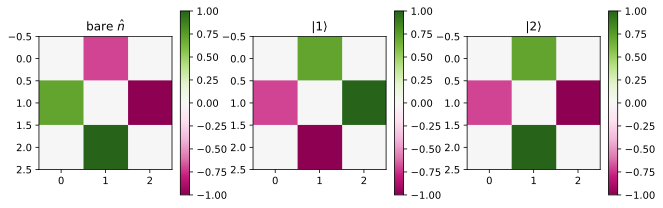

In [110]:
operator_dressed = system.hilbertspace.op_in_dressed_eigenbasis(system.osc.n_operator, truncated_dim = 400)
# operator_dressed = dressed_op

operator_bare = system.osc.n_operator()

fig, axes = plt.subplots(1, 3, figsize=(9, 3))  # 1 row, 3 columns

array1 = np.zeros((n_lvls, n_lvls))
for i in range(n_lvls):
    for j in range(n_lvls):
        array1[i, j] = np.imag(operator_bare[i, j])

array2 = np.zeros((n_lvls, n_lvls))
for i in range(n_lvls):
    for j in range(n_lvls):
        array2[i, j] = np.imag(operator_dressed[system.product_to_dressed[(1, i)], system.product_to_dressed[(1, j)]])

array3 = np.zeros((n_lvls, n_lvls))
for i in range(n_lvls):
    for j in range(n_lvls):
        array3[i, j] = np.imag(operator_dressed[system.product_to_dressed[(2, i)], system.product_to_dressed[(2, j)]])

arrays = [array1,array2,array3]
titles = [r'bare $\hat{{n}}$',r'$|1\rangle$', r'$|2\rangle$']
for i, ax in enumerate(axes):
    im = ax.imshow(arrays[i], cmap='PiYG', interpolation='nearest')
    ax.set_title(titles[i])
    fig.colorbar(im, ax=ax)  


plt.tight_layout()  # Adjust the layout to make room for the colorbar
plt.show()


# next question, is the sign in the dressed operator an error or it is what it is?

In [111]:
import scqubits.utils.spectrum_utils as spec_utils

truncated_dim = system.hilbertspace.dimension
op = system.osc.n_operator
op_in_bare_eigenbasis = False
subsys_index = 1

bare_evecs = system.hilbertspace._data["bare_evecs"][subsys_index][0]
id_wrapped_op = spec_utils.identity_wrap(
    op,
    system.hilbertspace.subsystem_list[subsys_index],
    system.hilbertspace.subsystem_list,
    op_in_eigenbasis=op_in_bare_eigenbasis,
    evecs=bare_evecs,
)
dressed_evecs = system.hilbertspace._data["evecs"][0]
dressed_op_data =  id_wrapped_op.transform(dressed_evecs).data.toarray()
dressed_op_truncated = qutip.Qobj(
    dressed_op_data[0:truncated_dim, 0:truncated_dim],
    dims=[[truncated_dim], [truncated_dim]],
)

## There's no problem with id_wrapped_op

In [113]:
for i in range(max_ol-1):
    print(id_wrapped_op.full().reshape(max_ql,max_ol,max_ql,max_ol)[1,i,1,i+1])

-0.7071067811865475j
-1j
-1.224744871391589j


## There's sign change after id_wrapped_op.transform(dressed_evecs)

In [115]:
for i in range(max_ol-1):
    print(dressed_op_truncated.full()[system.product_to_dressed[(1, i)], system.product_to_dressed[(1, i+1)]])

0.7071095432991693j
1.0000039060244994j
-1.2247166385014636j


In [116]:
type(id_wrapped_op)

qutip.qobj.Qobj

In [119]:
dressed_evecs[2].full()

array([[-3.30298340e-06+0.j],
       [ 0.00000000e+00+0.j],
       [-8.34019866e-07+0.j],
       [ 0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j],
       [-5.16039716e-04+0.j],
       [ 0.00000000e+00+0.j],
       [ 9.91277306e-10+0.j],
       [-9.99999867e-01+0.j],
       [ 0.00000000e+00+0.j],
       [ 1.87158586e-07+0.j],
       [ 0.00000000e+00+0.j]])

# The eigenstate represented in LC basis has a negative sign.

In [122]:
system.hilbertspace._data["evals"][0]

array([-0.67486167,  1.45262119,  1.49618185,  6.49034265,  8.61779043,
        8.66136859, 13.65554697, 15.78295967, 15.82655534, 20.82083441,
       22.94828973, 22.99174967])